# Summarize the Results

In [11]:
import os
import re
import numpy as np
import pandas as pd
import seaborn as sns
import pandas as pandas
import matplotlib.pyplot as plt

In [3]:
BASE_PATH = "/data/local/kgutjahr/results/test/runs/eval/ADNI"

In [4]:
def plot_grouped_heatmap(path: str):
    df = pd.read_csv(path).iloc[:, :-1]
    df = df.fillna(0)

    # Create combined Shift + Method column
    df['Shift_Method'] = df['Shift'] + " x " + df['Method']
    # Automatically select numeric columns
    
    numeric_cols = df.select_dtypes(include=['number']).columns

    # Set index for heatmap
    heatmap_df = df.set_index('Shift_Method')[numeric_cols]

    # Plot heatmap
    plt.figure(figsize=(10, 8))
    ax = sns.heatmap(heatmap_df, cmap="RdBu", annot=True, fmt=".1f", vmin=0, vmax=100)

    # Rotate labels
    plt.xticks(rotation=0)
    plt.yticks(rotation=0)

    # Add thick horizontal lines between Shifts
    shift_groups = df.groupby('Shift').size().cumsum()  # positions where each shift ends
    for pos in shift_groups[:-1]:  # skip the last line
        ax.hlines(pos, *ax.get_xlim(), colors='black', linewidth=3)

    plt.title("Heatmap of Accuracy (in %)", pad=20)
    plt.ylabel("Shift x Method", labelpad=20)
    plt.xlabel("Modality", labelpad=10)
    plt.tight_layout()
    plt.show()

In [6]:
def plot_heatmap(data):
    # Load CSV
    if isinstance(data, str):
        df = pd.read_csv(data)
    elif isinstance(data, pd.DataFrame):
        df = data
    else:
        raise TypeError("Wrong type")

    # Fill missing values with 0
    df = df.fillna(0)

    # Automatically select numeric columns
    numeric_cols = df.select_dtypes(include=['number']).columns

    # Set index with Shift + Method
    heatmap_df = df.set_index(["Shift"])[numeric_cols]

    # Plot heatmap with fixed color scale 0–100
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        heatmap_df,
        cmap="RdBu",
        annot=True,
        fmt=".4f",
        vmin=0,
        vmax=np.log(286)
    )
    # Rotate labels
    plt.xticks(rotation=0)
    plt.yticks(rotation=0)

    plt.title("Entropy STiL DVM (in %)")
    plt.ylabel("Dataset Shift")
    plt.xlabel("CLassifier")
    plt.tight_layout()
    plt.show()

In [91]:
def plot_one_grouped_df(df: pd.DataFrame, group_col: str, metrics: list[str], title: str, metric_name: str, markers=None):
    plt.figure(figsize=(8, 5))
    markers = ['o', 's', 'D', '^', 'v', '<', '>', 'p', '*', 'h']

    x = df[group_col] if group_col in df.columns else df.index

    for i, metric in enumerate(metrics):
        # handle MultiIndex columns
        if isinstance(df.columns, pd.MultiIndex):
            mean = df[(metric, "mean")]
            std = df[(metric, "std")]
        else:
            mean = df[f"{metric}.mean"]
            std = df[f"{metric}.std"]

        plt.plot(x, mean, label=metric, marker=markers[i % len(markers)], linewidth=2)
        plt.fill_between(x, mean - std, mean + std, alpha=0.2)

    plt.title(title)
    plt.xlabel(group_col.capitalize() if group_col else "Index")
    plt.ylabel(f"{metric_name} (mean ± std)")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

In [74]:
def plot_two_grouped_df(df: pd.DataFrame, first_group_col: str, second_group_col: str, metric: str, title: str):
    plt.figure(figsize=(8, 5))

    # loop over each name
    for name, subdf in df.groupby(second_group_col):
        eps = subdf[first_group_col]
        mean = subdf[metric]["mean"]
        std = subdf[metric]["std"]

        plt.plot(eps, mean, label=name, marker="o", linewidth=2)
        plt.fill_between(eps, mean - std, mean + std, alpha=0.2)

    plt.title(title)
    plt.xlabel(first_group_col.capitalize())
    plt.ylabel(f"{metric} (mean ± std)")
    plt.legend(title="Distribution Shift")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

In [15]:
def create_one_group_df(dir_path: str, filename: str) -> pd.DataFrame:
    df = pd.DataFrame()
    for subdir in os.listdir(dir_path):
        subdir_path = os.path.join(dir_path, subdir)
        if not os.path.isdir(subdir_path):
            continue
        for file in os.listdir(subdir_path):
            file_path = os.path.join(dir_path, subdir, file)
            if not file.startswith(filename) or not os.path.isfile(file_path):
                continue
            file_df = pd.read_csv(file_path)
            file_df["name"] = subdir.split("_")[0]
            if df.empty:
                df = file_df
            else:
                df = pd.concat([df, file_df], axis=0)
    return df.reset_index(drop=True)

In [34]:
def create_two_group_df(dir_path: str, filename: str, group_col: str) -> pd.DataFrame:
    df = pd.DataFrame()
    pattern = re.compile(r"consent_(\d+(?:\.\d+)?)_([a-zA-Z]+)")  # match e.g. consent_0_age

    for subdir in os.listdir(dir_path):
        subdir_path = os.path.join(dir_path, subdir)
        if not os.path.isdir(subdir_path):
            continue

        # extract number and word after "consent_"
        match = pattern.search(subdir)
        consent_num, consent_label = (None, None)
        if match:
            consent_num = match.group(1)
            consent_label = match.group(2)

        for file in os.listdir(subdir_path):
            file_path = os.path.join(subdir_path, file)
            if not file.startswith(filename) or not os.path.isfile(file_path):
                continue

            file_df = pd.read_csv(file_path)
            file_df["name"] = subdir.split("_")[0]
            file_df[group_col] = consent_num
            file_df["name"] = consent_label

            df = pd.concat([df, file_df], axis=0, ignore_index=True)

    return df

In [65]:
def make_df_numeric(df: pd.DataFrame):
    def parse_tensor_string(x):
        if isinstance(x, str) and x.startswith("tensor"):
            return float(x.split("(")[1].rstrip(")"))
        return x
    
    return df.applymap(parse_tensor_string)

In [8]:
def summarize_df(df: pd.DataFrame, group_col: str) -> pd.DataFrame:
    return df.groupby(group_col).agg(['mean', 'std'])

In [30]:
def summarize_two_groups_df(df: pd.DataFrame, first_group_col: str, second_group_col: str) -> pd.DataFrame:
    numeric_cols = df.select_dtypes(include=["number"]).columns

    # group by epsilon and name, then compute mean and std for numeric columns
    grouped = (
        df.groupby([first_group_col, second_group_col])[numeric_cols]
          .agg(["mean", "std"])
          .reset_index()
    )
    
    return grouped

## Baseline

In [57]:
baseline_path = os.path.join(BASE_PATH, "baseline")
df = create_one_group_df(dir_path=baseline_path, filename="test")
summed_df_baseline_test = summarize_df(df=df, group_col="name")
summed_df_baseline_test

multimodal.test.classifier.entropy            \
                                     mean       std   
name                                                  
TE                               0.607700  0.047916   
age                              0.537206  0.101856   
normal                           0.503943  0.001517   
weight                           0.489874  0.036939   

       image.test.classifier.entropy            \
                                mean       std   
name                                             
TE                          1.039594  0.026097   
age                         1.035215  0.017957   
normal                      1.013813  0.000598   
weight                      1.036768  0.022576   

       tabular.test.classifier.entropy            test.acc            \
                                  mean       std      mean       std   
name                                                                   
TE                            0.651024  0.054470  0.830252  0.005315   
age                           0.564431  0.099658  0.812727  0.006356   
normal                        0.580573  0.000739  0.842241  0.004164   
weight                        0.502532  0.019367  0.840833  0.012076   

        test.auc            
            mean       std  
name                        
TE      0.936569  0.006186  
age     0.891711  0.008411  
normal  0.935455  0.001200  
weight  0.941193  0.007299

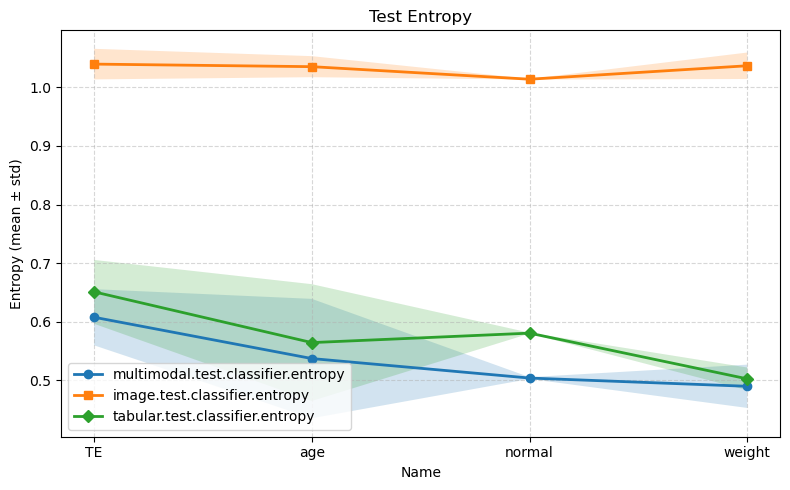

In [92]:
plot_one_grouped_df(summed_df_baseline_test, group_col="name", metrics=["multimodal.test.classifier.entropy", "image.test.classifier.entropy", "tabular.test.classifier.entropy"], title="Test Entropy", metric_name="Entropy")

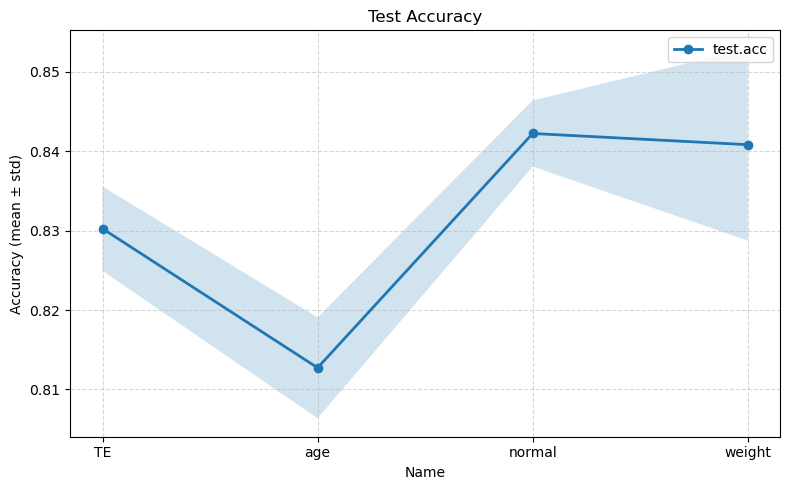

In [95]:
plot_one_grouped_df(summed_df_baseline_test, group_col="name", metrics=["test.acc"], title="Test Accuracy", metric_name="Accuracy")

In [70]:
baseline_path = os.path.join(BASE_PATH, "baseline")
df_baseline_eval = create_one_group_df(dir_path=baseline_path, filename="eval")
df_baseline_eval =  make_df_numeric(df=df_baseline_eval[["name", "multimodal.classifier.entropy", "image.classifier.entropy", "tabular.classifier.entropy", "classifier.multi.acc", "classifier.image.acc", "classifier.tab.acc"]])
summed_df_baseline_eval = summarize_df(df=df_baseline_eval, group_col="name")
summed_df_baseline_eval

multimodal.classifier.entropy           image.classifier.entropy  \
                                mean       std                     mean   
name                                                                      
TE                           0.57631  0.020011                  1.02581   
age                          0.52803  0.010485                  1.03490   
normal                       0.55597  0.004103                  1.04093   
weight                       0.55399  0.012868                  1.02716   

                 tabular.classifier.entropy           classifier.multi.acc  \
             std                       mean       std                 mean   
name                                                                         
TE      0.005789                    0.58821  0.018710              0.75895   
age     0.015370                    0.53323  0.019364              0.78243   
normal  0.001604                    0.56902  0.002199              0.76618   
weight  0.013888                    0.56079  0.017833              0.76480   

                 classifier.image.acc           classifier.tab.acc            
             std                 mean       std               mean       std  
name                                                                          
TE      0.006508              0.48709  0.000601            0.76121  0.008292  
age     0.025493              0.46055  0.005453            0.77701  0.019963  
normal  0.004263              0.48281  0.003635            0.76711  0.002360  
weight  0.005666              0.48727  0.001170            0.76646  0.006717

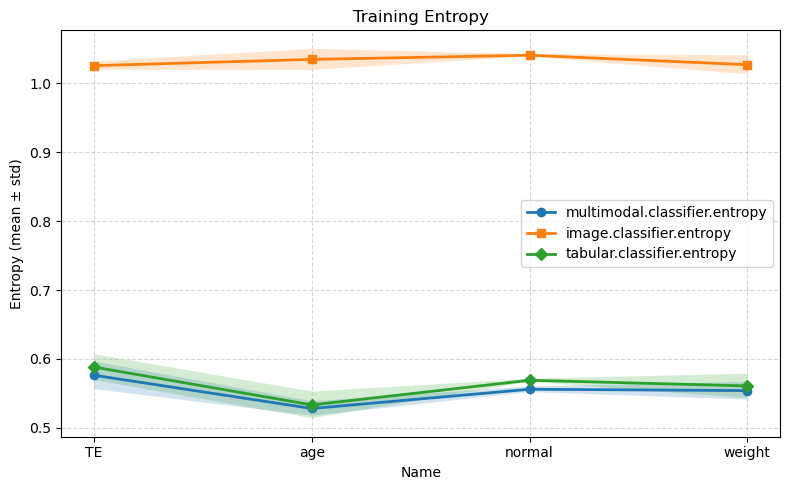

In [93]:
plot_one_grouped_df(summed_df_baseline_eval, group_col="name", metrics=["multimodal.classifier.entropy", "image.classifier.entropy", "tabular.classifier.entropy"], title="Training Entropy", metric_name="Entropy")

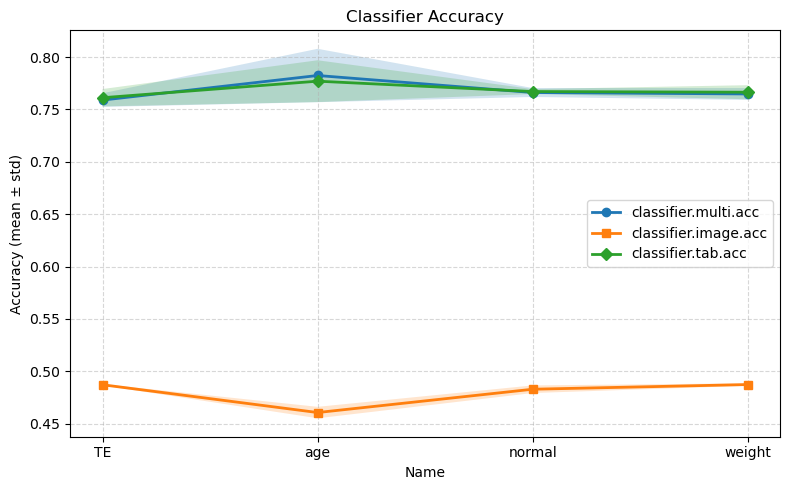

In [96]:
plot_one_grouped_df(summed_df_baseline_eval, group_col="name", metrics=["classifier.multi.acc", "classifier.image.acc", "classifier.tab.acc"], title="Classifier Accuracy", metric_name="Accuracy")

## Trainable Consent

In [77]:
consent_path = os.path.join(BASE_PATH, "train_consent")
group_col = "epsilon"
df_c = create_two_group_df(dir_path=consent_path, filename="test", group_col=group_col)
summed_c_df = summarize_two_groups_df(df=df_c, first_group_col=group_col, second_group_col="name")

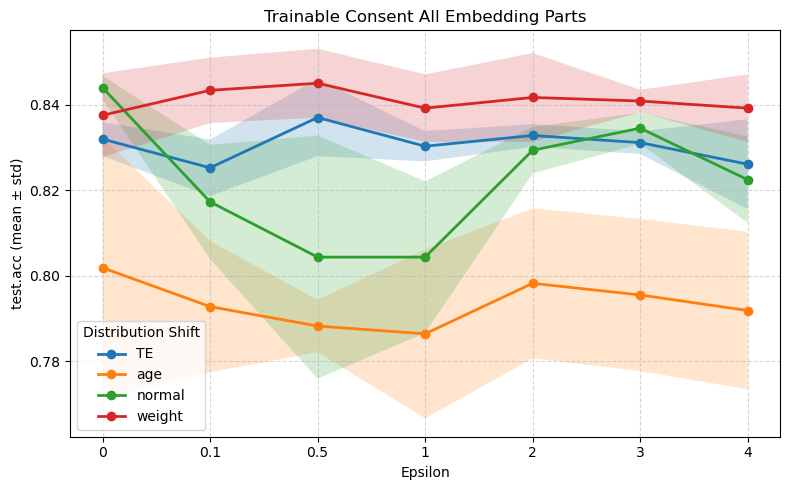

In [ ]:
plot_two_grouped_df(df=summed_c_df, first_group_col=group_col, second_group_col="name", metric="test.acc", title="Trainable Consent All Embedding Parts")